# Telecom Customer Churn Prediction

This project predicts whether a telecom customer will churn (leave the service) or not using machine learning.

We use the K-Nearest Neighbors (KNN) algorithm to classify customers based on their usage behavior and service interactions.

Target:
- 1 = Customer will churn
- 0 = Customer will not churn

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

Load Dataset

In [ ]:
churn_df = pd.read_csv("https://github.com/DataAnalyst21/DatasetsForDataAnalytics/blob/main/telecom_churn_clean.csv?raw=True")

churn_df.head()

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Define Features & Target

In [ ]:
X = churn_df.drop("churn", axis=1).values
y = churn_df["churn"].values

Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Model

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

Evaluate Model

In [ ]:
print("Training Accuracy:", knn.score(X_train, y_train))
print("Testing Accuracy:", knn.score(X_test, y_test))

Training Accuracy: 0.878469617404351
Testing Accuracy: 0.8545727136431784


Find Best K

In [ ]:
neighbors = np.arange(1, 13)

train_acc = {}
test_acc = {}

for k in neighbors:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_acc[k] = model.score(X_train, y_train)
    test_acc[k] = model.score(X_test, y_test)

Visualization

## Model Complexity Graph Summary

The graph shows how the K-Nearest Neighbors (KNN) model performance changes as the number of neighbors (K) increases.

- When K is very small (e.g., K = 1), the training accuracy is very high, but the test accuracy is low. This indicates overfitting, where the model memorizes the training data but performs poorly on new data.

- As K increases, the test accuracy improves and becomes more stable, showing better generalization.

- At higher K values, both training and test accuracy become closer, meaning the model is more balanced and less sensitive to noise.

From the graph, the best performance is achieved around K = 8, where the model shows a good balance between training and testing accuracy.

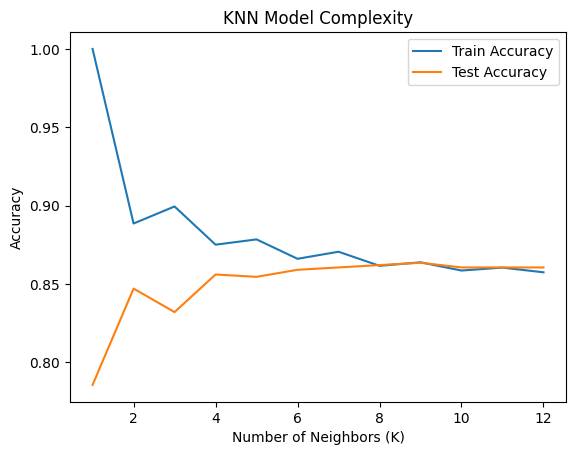

In [ ]:
plt.title("KNN Model Complexity")

plt.plot(neighbors, train_acc.values(), label="Train Accuracy")
plt.plot(neighbors, test_acc.values(), label="Test Accuracy")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Final Model Selection

Based on the model complexity analysis, K = 8 was selected as the optimal number of neighbors because it provides the best balance between training and testing accuracy. This value reduces overfitting while maintaining strong generalization performance.

Therefore, the final KNN model is trained using K = 8 to make more reliable predictions on new customer data, including the three new entries.

In [ ]:
X = churn_df[["account_length", "customer_service_calls"]].values
y = churn_df["churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

final_knn = KNeighborsClassifier(n_neighbors=8)
final_knn.fit(X_train, y_train)

# Now prediction works with 2 features
new_customers = np.array([
    [120, 2],
    [50, 10],
    [200, 1]
])

predictions = final_knn.predict(new_customers)

print(predictions)

[0 0 0]
